**Project Title - Detection of Emotion of Speech using Hybrid CNN**

Install required libraries

In [2]:
# Install all necessary libraries
# kaggle: download dataset
# librosa: audio processing
# tensorflow: model training
# scikit-learn: evaluation & preprocessing
# matplotlib, seaborn: plotting
!pip install kaggle librosa tensorflow scikit-learn matplotlib seaborn

Create Kaggle API token

In [5]:
import json
import os

# Replace with your Kaggle username and API key
kaggle_username = "satyamraj4072"
kaggle_key = "KGAT_0e753f1cf04700a1e59a6b675df9a200"

# Create folder ~/.kaggle if not exists
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)

# Save credentials in kaggle.json
with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
    json.dump({"username": kaggle_username, "key": kaggle_key}, f)

# Set file permission
os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)

print("kaggle.json created successfully!")

kaggle.json created successfully!


Download RAVDESS Emotional Speech Dataset

In [6]:
# Download dataset directly from Kaggle
!kaggle datasets download -d uwrfkaggler/ravdess-emotional-speech-audio

Dataset URL: https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio
License(s): CC-BY-NC-SA-4.0
 94% 403M/429M [00:00<00:00, 473MB/s]
100% 429M/429M [00:00<00:00, 525MB/s]


Extract ZIP file

In [7]:
import zipfile

zip_file = "ravdess-emotional-speech-audio.zip"
extract_path = "/content/ravdess-emotional-speech-audio"

# Extract all files
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"Dataset extracted to {extract_path}")

Dataset extracted to /content/ravdess-emotional-speech-audio


Explore dataset structure

In [8]:
import os

# Show first 10 folders (actors)
print("Sample folders in dataset:")
sample_folders = os.listdir(extract_path)[:10]
for f in sample_folders:
    print(f)

# Count total .wav files inside all subfolders
total_files = sum([len(files) for r, d, files in os.walk(extract_path) if files])
print(f"Total .wav files in dataset: {total_files}")

Sample folders in dataset:
Actor_20
Actor_15
Actor_22
Actor_08
Actor_17
Actor_21
Actor_23
Actor_16
Actor_24
Actor_18
Total .wav files in dataset: 2880


Map emotion codes to labels

In [9]:
# RAVDESS filenames contain emotion codes
emotions_map = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

Define function to extract MFCC features

In [13]:
import librosa
import numpy as np

def extract_features(file_path, n_mfcc=40):
    """
    Load a .wav file and extract MFCC features.
    Returns MFCC array (time_steps, n_mfcc)
    """
    audio, sr = librosa.load(file_path, sr=16000)  # load audio at 16kHz
    mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
    return mfccs.T  # transpose to (time_steps, n_mfcc)

Load dataset and extract features/labels

In [14]:
X = []  # store features
y = []  # store emotion labels

# Traverse all folders & files
for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.endswith(".wav"):
            file_path = os.path.join(root, file)
            emotion_code = file.split("-")[2]  # 3rd field in filename
            emotion_label = emotions_map.get(emotion_code)
            if emotion_label is None:
                continue
            mfccs = extract_features(file_path)
            X.append(mfccs)
            y.append(emotion_label)

print(f"Total samples loaded: {len(X)}")
print(f"Example label: {y[0]}, MFCC shape: {X[0].shape}")

Total samples loaded: 2880
Example label: sad, MFCC shape: (109, 40)


Encode labels and pad sequences

In [15]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Encode labels as integers
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_onehot = to_categorical(y_encoded)

# Pad sequences so all have same length
max_len = max([mfcc.shape[0] for mfcc in X])
X_padded = pad_sequences(X, maxlen=max_len, dtype='float32', padding='post')

# Add channel dimension for CNN
X_padded = X_padded[..., np.newaxis]

print("Input shape:", X_padded.shape)
print("Labels shape:", y_onehot.shape)

Input shape: (2880, 165, 40, 1)
Labels shape: (2880, 8)


Split dataset into training/testing sets

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_padded, y_onehot, test_size=0.2, random_state=42, stratify=y_onehot
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 2304
Testing samples: 576


Build Hybrid CNN model

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

# Conv block 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=X_train.shape[1:]))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.3))

# Conv block 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.3))

# Flatten & dense layers
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(y_onehot.shape[1], activation='softmax'))  # output layer

# Compile model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 163, 38, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 81, 19, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 81, 19, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 79, 17, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 39, 8, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 39, 8, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 19968)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     2,556,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,575,880 (9.83 MB)

 Trainable params: 2,575,880 (9.83 MB)

 Non-trainable params: 0 (0.00 B)

Train the model

In [21]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 25s 291ms/step - accuracy: 0.1313 - loss: 20.8298 - val_accuracy: 0.1667 - val_loss: 2.0343
Epoch 2/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 299ms/step - accuracy: 0.1713 - loss: 2.0431 - val_accuracy: 0.1962 - val_loss: 2.0052
Epoch 3/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 21s 286ms/step - accuracy: 0.1775 - loss: 2.0365 - val_accuracy: 0.2014 - val_loss: 1.9830
Epoch 4/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 23s 323ms/step - accuracy: 0.1804 - loss: 2.0110 - val_accuracy: 0.2344 - val_loss: 1.9103
Epoch 5/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 39s 295ms/step - accuracy: 0.2111 - loss: 1.9524 - val_accuracy: 0.2656 - val_loss: 1.8749
Epoch 6/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 40s 279ms/step - accuracy: 0.2351 - loss: 1.9037 - val_accuracy: 0.2795 - val_loss: 1.8014
Epoch 7/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 22s 294ms/step - accuracy: 0.2720 - loss: 1.8256 - val_accuracy: 0.3490 - val_loss: 1.6977
Epoch 8/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 20s 277ms/step - accuracy: 0.2937 - loss: 1.7800 - val_acc

Evaluate model & plot results

Test Accuracy: 92.36%


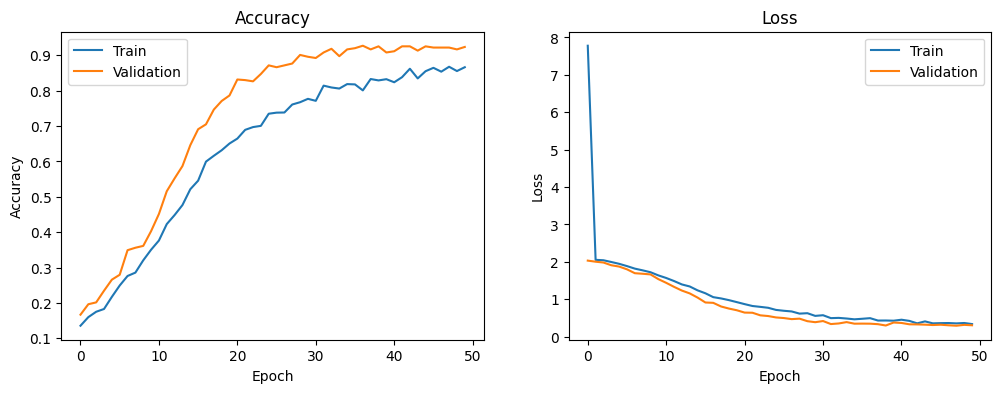

In [24]:
import matplotlib.pyplot as plt

# Test accuracy
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc*100:.2f}%")

# Plot accuracy and loss curves
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

Classification report & confusion matrix

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step
Classification Report:
              precision    recall  f1-score   support

       angry       0.93      0.97      0.95        77
        calm       0.97      0.91      0.94        77
     disgust       0.90      0.94      0.92        77
     fearful       0.93      0.97      0.95        77
       happy       0.92      0.86      0.89        77
     neutral       0.82      0.87      0.85        38
         sad       0.90      0.84      0.87        77
   surprised       0.97      1.00      0.99        76

    accuracy                           0.92       576
   macro avg       0.92      0.92      0.92       576
weighted avg       0.92      0.92      0.92       576



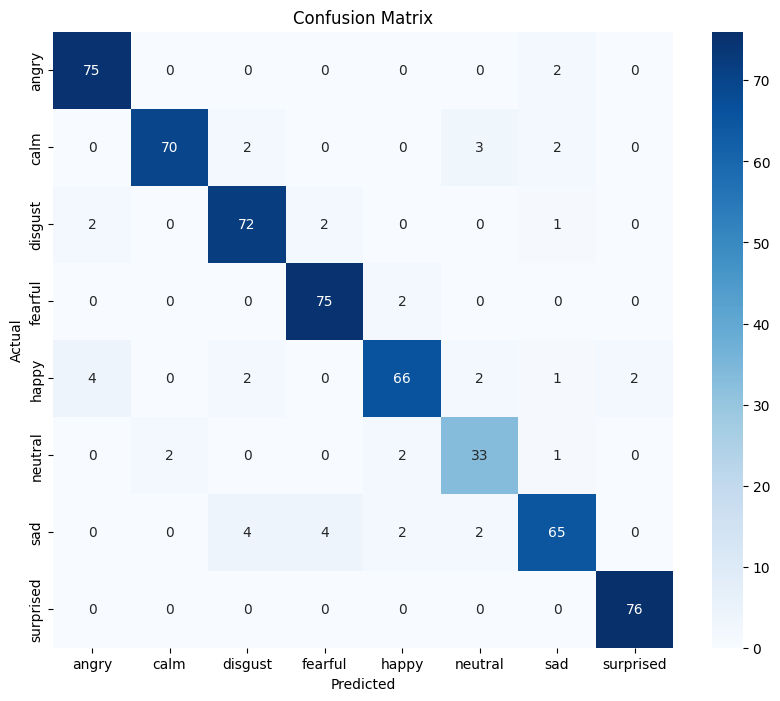

In [26]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Manual prediction from .wav file

In [28]:
from google.colab import files

# Upload any .wav file to predict emotion
uploaded = files.upload()

def predict_emotion(file_path):
    mfccs = extract_features(file_path)
    mfccs_padded = pad_sequences([mfccs], maxlen=max_len, dtype='float32', padding='post')
    mfccs_padded = mfccs_padded[..., np.newaxis]
    prediction = model.predict(mfccs_padded)
    predicted_index = np.argmax(prediction)
    emotion_label = le.inverse_transform([predicted_index])[0]
    return emotion_label

for file_name in uploaded.keys():
    predicted_emotion = predict_emotion(file_name)
    print(f"Predicted Emotion for '{file_name}': {predicted_emotion}")

Saving 03-01-02-01-02-01-15.wav to 03-01-02-01-02-01-15.wav
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Predicted Emotion for '03-01-02-01-02-01-15.wav': calm
